In [1]:
import pandas as pd 
import platform
import matplotlib.pyplot as plt

- csv 폴더 안에 card 폴더의 데이터를 로드 
- offline.csv 파일을 로드 (카드 사용내역 데이터)
    1. 컬럼의 이름을 변경 -> 항목 정의서 파일이 존재 (제공하는 데이터에 대한 설명)
    2. 결측치가 존재하는가? -> 결측치를 대체 
    3. 시간 데이터 컬럼을 시계열데이터로 타입은 변환

In [3]:
offline = pd.read_csv('../csv/card/오프라인.csv', encoding='CP949')

In [4]:
offline.head()

,crym,tco_btc_nm,ma_fem_dc,agegrp_dc,tco_btc_u_ct,tco_btc_u_am
0,201901,백화점,1,1,1,7.600000e+03
1,201901,백화점,1,10,379,1.945872e+07
2,201901,백화점,1,20,45173,4.747711e+09
3,201901,백화점,1,30,271858,2.791826e+10
4,201901,백화점,1,40,391109,3.791149e+10


In [5]:
# 항목정의서 엑셀 파일을 로드 
col_info = pd.read_excel(
    "../csv/card/(수정)(항목정의서)유통+업종+카드소비트랜드+데이터_20211101.xlsx"
)

In [9]:
offline.columns = col_info['데이터 컬럼'].to_list()

In [10]:
offline.head(1)

,기준년월,업종 구분,성별,연령대,이용 건수,이용 금액
0,201901,백화점,1,1,1,7600.0


In [11]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   기준년월    2648 non-null   int64  
 1   업종 구분   2648 non-null   object 
 2   성별      2648 non-null   int64  
 3   연령대     2648 non-null   int64  
 4   이용 건수   2648 non-null   int64  
 5   이용 금액   2648 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 124.3+ KB


In [13]:
# 항목정의서를 기준으로 성별에서 '-'가 결측치이다. 
# '-'의 개수를 확인 
# 조건식을 이용한다. 성별데이터에서 '-'와 같은 데이터
(offline['성별'] == '-').sum()

np.int64(0)

In [14]:
# 성별 데이터에서 데이터들의 개수를 확인 
offline['성별'].value_counts()

성별
2    1336
1    1312
Name: count, dtype: int64

In [16]:
# 성별에 1, 2만 존재하는가? -> 1 이거나(or) 2 인 경우 
# 포함 여부 -> isin()
offline['성별'].isin( [1,2] ).all()

np.True_

In [17]:
# 고유값을 출력하자
offline['성별'].unique()

array([1, 2])

In [ ]:
# 기준년월 데이터의 타입을 시계열데이터로 변경 
# datetime 라이브러리 안에 strptime() 함수를 이용하여 변경 
# pandas안에 Series에서 제공하는 to_datetime() 함수를 이용하여 변경 

In [18]:
from datetime import datetime

In [27]:
# datetime안에 strptime() -> 문자를 시계열 데이터로 변환 
datetime.strptime(
    str(offline['기준년월'][0]), 
    '%Y%m'
)

datetime.datetime(2019, 1, 1, 0, 0)

In [28]:
offline['기준년월'].map(
    lambda x : datetime.strptime( str(x), '%Y%m' )
)

0      2019-01-01
1      2019-01-01
2      2019-01-01
3      2019-01-01
4      2019-01-01
          ...    
2643   2021-09-01
2644   2021-09-01
2645   2021-09-01
2646   2021-09-01
2647   2021-09-01
Name: 기준년월, Length: 2648, dtype: datetime64[ns]

In [31]:
# pandas에 내장된 to_dateime() 
# format 매개변수 존재 -> 선택 항목 (pandas에는 범용적으로 사용이 되는 시계열포멧이 존재)
offline['기준년월'] = pd.to_datetime( offline['기준년월'] , format='%Y%m')

In [32]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   기준년월    2648 non-null   datetime64[ns]
 1   업종 구분   2648 non-null   object        
 2   성별      2648 non-null   int64         
 3   연령대     2648 non-null   int64         
 4   이용 건수   2648 non-null   int64         
 5   이용 금액   2648 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 124.3+ KB


In [33]:
# 파생변수 생성 -> 월 컬럼을 생성 -> 기준년월에서 월만 따로 추출 
# 시계열데이터에서 월을 추출한다.(strftime())
offline['기준년월'].map(
    lambda x : x.strftime('%m')
)

0       01
1       01
2       01
3       01
4       01
        ..
2643    09
2644    09
2645    09
2646    09
2647    09
Name: 기준년월, Length: 2648, dtype: object

In [ ]:
# Series에서 문자열(str), 시계열(dt) 메소드에 접근하는 방법 
offline['기준년월'].dt.strftime('%m')

In [37]:
offline['기준월'] = offline['기준년월'].dt.month

In [38]:
# 기준월 별 이용 금액의 평균을 막대그래프 표시 
month_df = offline[ ['기준월', '이용 금액'] ].groupby('기준월').mean()
month_df

,이용 금액
기준월,
1,1.074901e+10
2,9.589884e+09
3,1.041977e+10
4,1.056234e+10
5,1.122180e+10
6,1.054029e+10
7,1.023200e+10
8,1.048811e+10
9,1.071814e+10


In [39]:
# 그래프의 한글 깨짐 방지 
if platform.system() == 'Darwin':
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')

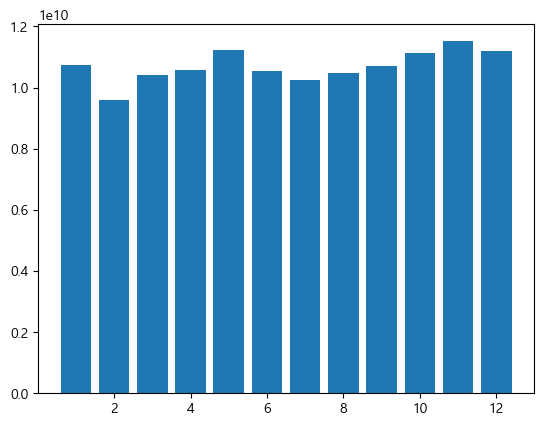

In [40]:
plt.bar(month_df.index, month_df['이용 금액'])

plt.show()

<Axes: xlabel='기준월'>

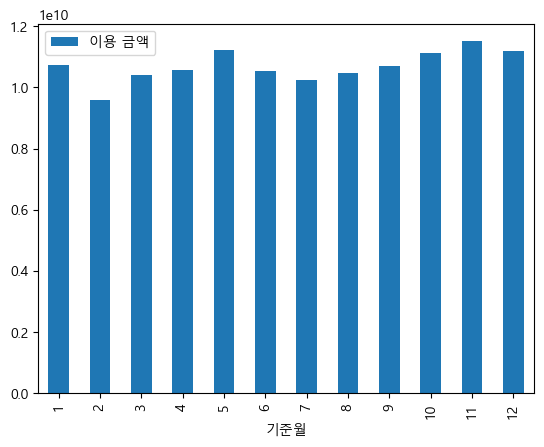

In [43]:
month_df.plot(kind='bar')

<Axes: xlabel='기준월'>

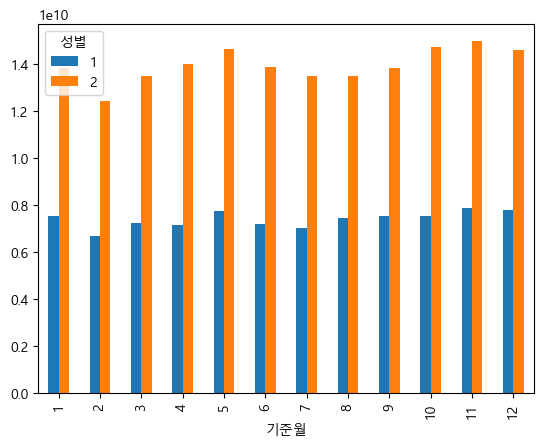

In [46]:
# 월별, 성별을 기준으로 이용 금액의 평균을 그래프 표시 
pd.pivot_table(
    offline, 
    index = '기준월', 
    columns= '성별', 
    values= '이용 금액', 
    aggfunc= 'mean'
).plot(kind='bar')

In [ ]:
# 기준년월별 업종별로 이용 금액의 합계를 그래프(선 그래프)로 표시 
offline['업종 구분'].unique()

array(['백화점', '할인점', '슈퍼마켓', '편의점'], dtype=object)

<Axes: xlabel='기준년월'>

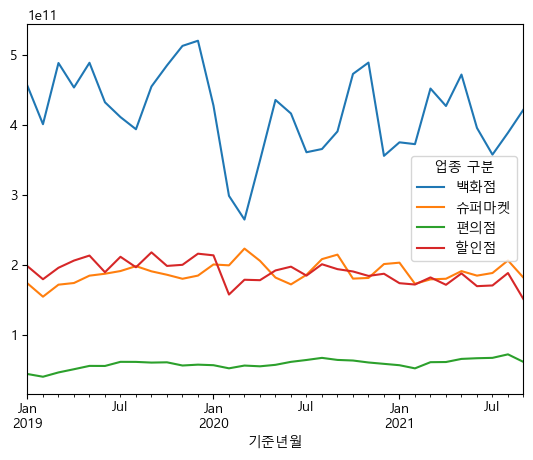

In [50]:
pd.pivot_table(
    offline, 
    index = '기준년월', 
    columns= '업종 구분', 
    values = '이용 금액', 
    aggfunc= 'sum'
).plot()

In [52]:
group_data = offline[ ['기준년월', '업종 구분', '이용 금액'] ].groupby(['기준년월', '업종 구분']).sum()

In [56]:
group_data

이용 금액
기준년월       업종 구분              
2019-01-01 백화점    4.558955e+11
           슈퍼마켓   1.736131e+11
           편의점    4.408358e+10
           할인점    1.981718e+11
2019-02-01 백화점    4.011916e+11
...                        ...
2021-08-01 할인점    1.884296e+11
2021-09-01 백화점    4.220812e+11
           슈퍼마켓   1.818095e+11
           편의점    6.136282e+10
           할인점    1.510796e+11

[132 rows x 1 columns]

<Axes: xlabel='기준년월'>

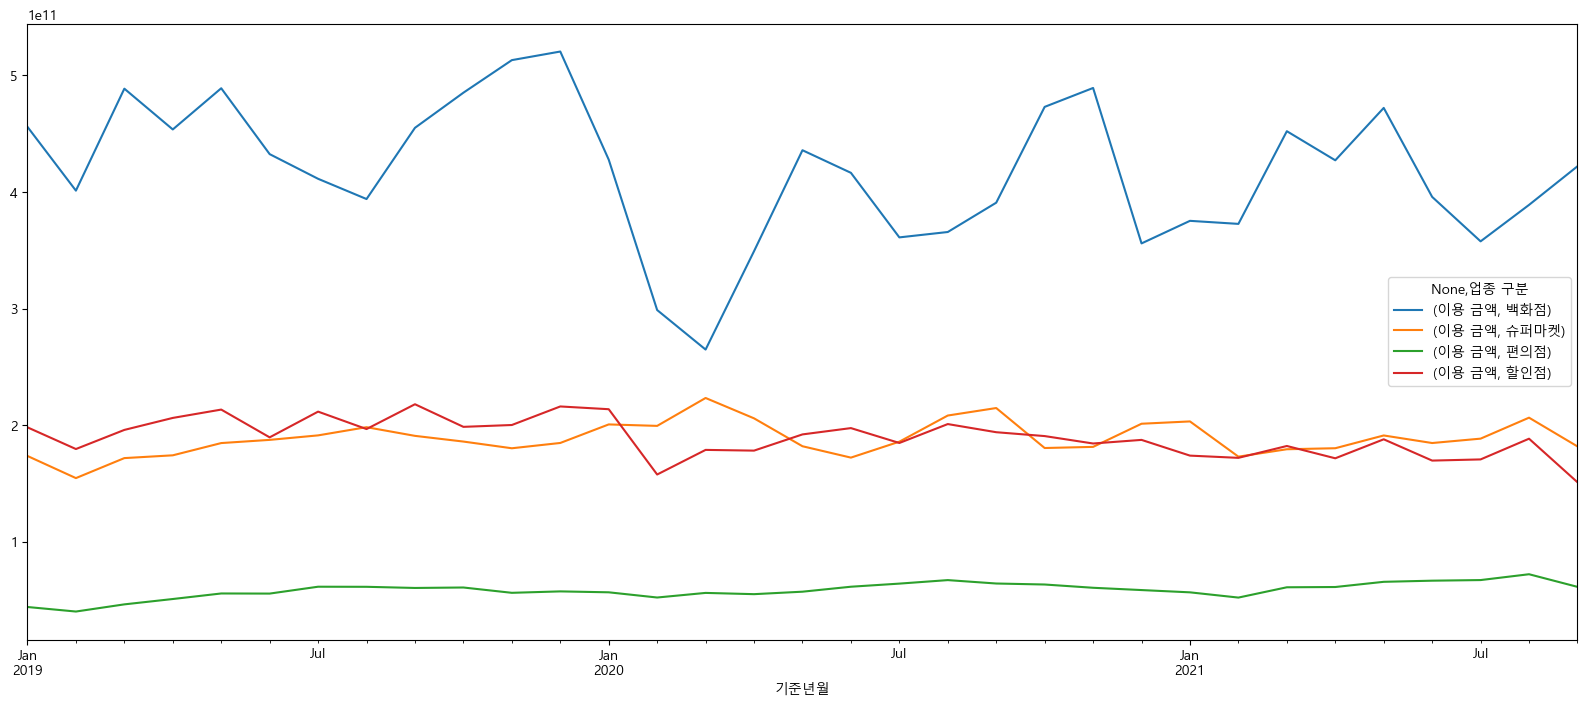

In [57]:

group_data.unstack().plot(figsize=(20, 8))

In [58]:
# 연령대 데이터가 어떤 데이터가 있는지 확인 
offline['연령대'].value_counts()

연령대
10    264
20    264
30    264
70    264
40    264
50    264
60    264
90    264
80    264
0     233
1      39
Name: count, dtype: int64

In [59]:
offline.columns

Index(['기준년월', '업종 구분', '성별', '연령대', '이용 건수', '이용 금액', '기준월'], dtype='object')

In [60]:
# 파생 변수 -> 건당 이용금액 -> 남, 여 건당 이용금액의 차이가 존재할것인가?
offline['건당이용금액'] = offline['이용 금액'] / offline['이용 건수']

<Axes: xlabel='성별'>

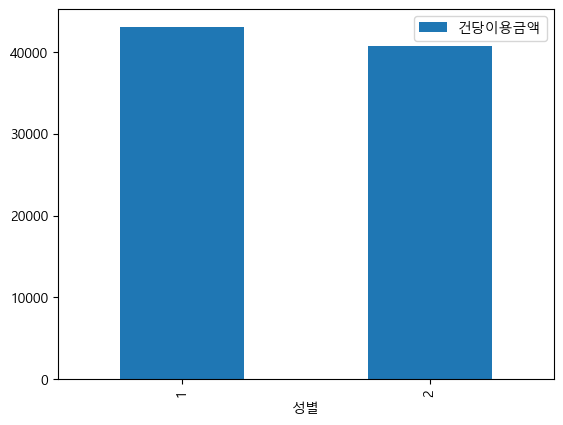

In [62]:
pd.pivot_table(
    offline, 
    index = '성별', 
    values = '건당이용금액', 
    aggfunc= 'mean'
).plot(kind='bar')

In [ ]:
# matplot에서 여러개의 영역을 나눠서 그래프 그린다. 
plt.figure(figsize=(20, 8))
# subplot( row(행의 개수), cols(열의 개수), position(위치) )
plt.subplot(2, 1, 1)
plt.plot( [1,2,3,4,5] )
plt.subplot(2, 1, 2)
plt.bar( [1,2,3], [50, 30, 40] )
plt.show()

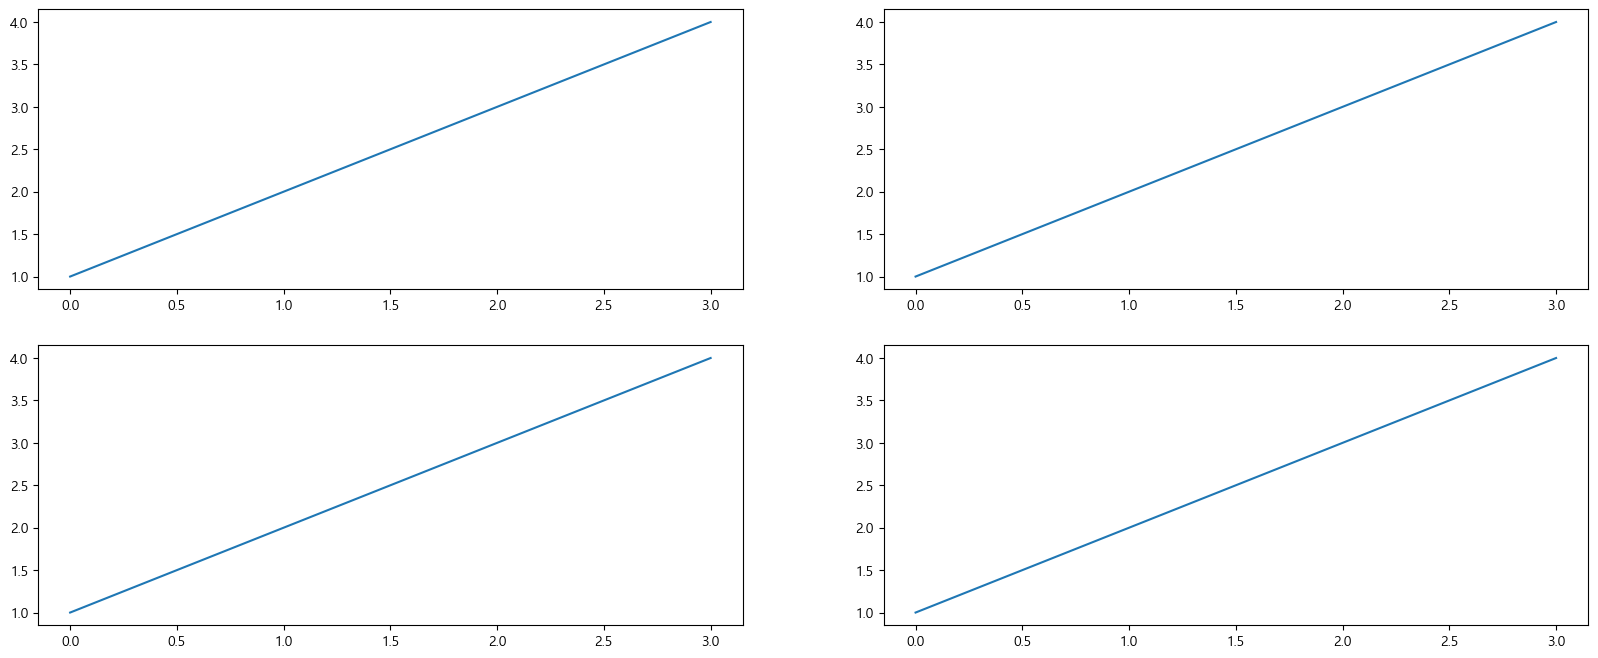

In [70]:
# subplots() -> 영역을 나눠주는 함수 -> 영역을 나눈 캔버스를 생성 -> 앞에서 생성한 캔버스의 크기는 초기화하고 새로 생성 
# 2개의 데이터를 되돌려준다. 캔버스, 캔버스 영역
# plt.figure(figsize = (20, 8))
# plt.bar([1,2,3], [40,30, 10])
fig, axes = plt.subplots(2, 2, figsize = (20, 8))

axes[0][0].plot([1,2,3,4])
axes[0][1].plot([1,2,3,4])
axes[1][0].plot([1,2,3,4])
axes[1][1].plot([1,2,3,4])




In [ ]:
# 연령대 별로 그래프를 따로 생성 
group_data2 = pd.pivot_table(
    offline, 
    index = '기준년월', 
    columns = '연령대', 
    values = '이용 금액', 
    aggfunc= 'sum'
)
group_data2

In [ ]:
group_data2.plot()

In [74]:
len(
    offline['연령대'].unique()
)

11

In [ ]:
group_data2[10]

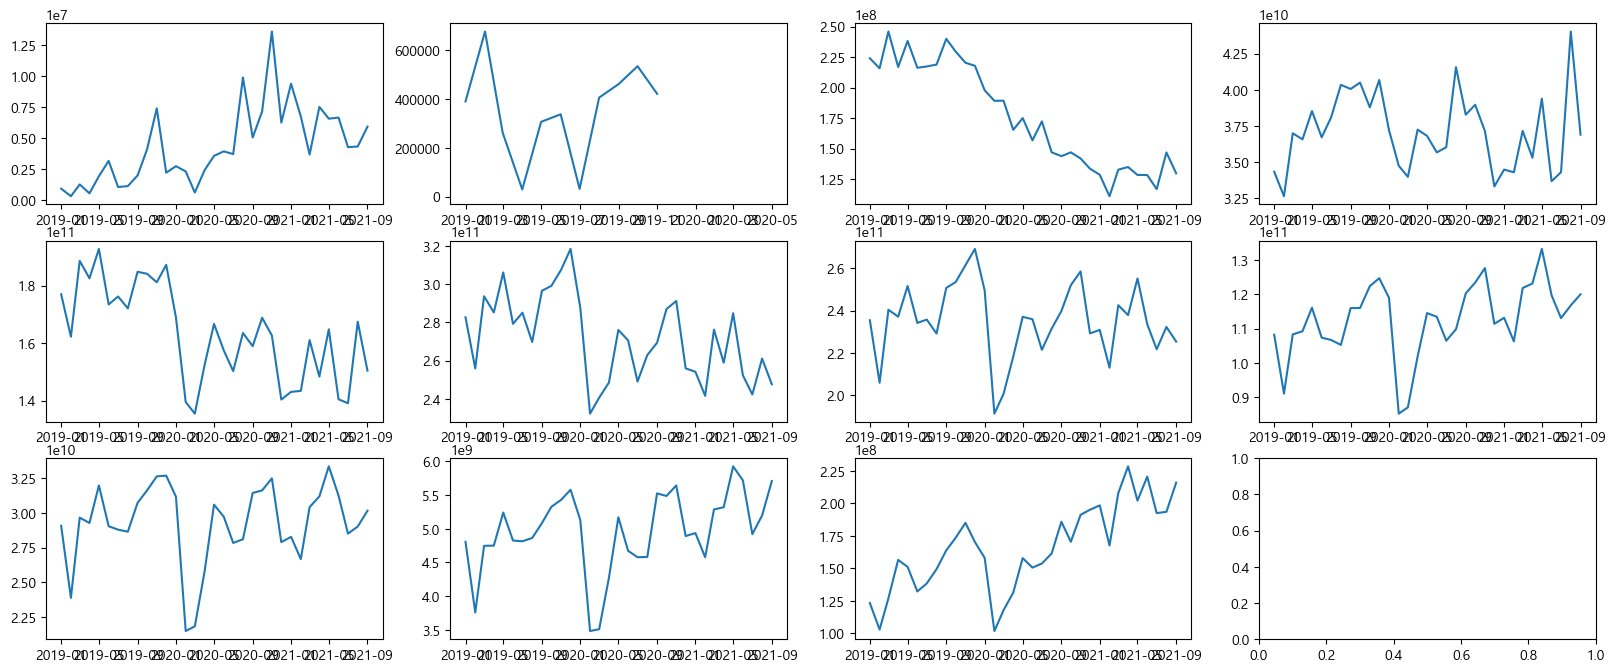

In [85]:
row_num = 3
col_num = 4
fig, axes = plt.subplots(row_num, col_num, figsize=(20, 8))

for i in range( len(group_data2.columns) ):
    # i -> 0부터 10까지 대입 
    # row 위치의 조건은? -> 4로 나눈 몫
    row = i // col_num
    # col 위치의 조건은? -> 4로 나눈 나머지 
    cols = i % col_num
    axes[row][cols].plot( group_data2.iloc[:, i] )

In [ ]:
# 행을 4개로 열을 3개로 해서 subplot()을 이용
# subplot(row, cols, position) -> 위치의 값은 좌에서 우로 위에서 아래로 위치가 잡힘

# 캔버스 사이즈 지정 
plt.figure(figsize=(20, 12))

for i in range( len(group_data2.columns) ):
    # i는 0부터 10까지 
    plt.subplot(4, 3, i+1)
    plt.plot( group_data2.iloc[:, i] )

plt.show()

#### 문제 
1. offline 데이터에서 기준년월, 업종, 성별 별로 총 이용금액의 합계 라인 그래프로 표시 
    - 8개 데이터를 각각 그래프를 생성
    - subplot(), subplots() 를 이용해서 하나의 캔버스에 그래프를 생성 
    - 생성된 그래프를 이미지로 저장 
    - 행을 4 열은 2개

In [ ]:
pd.pivot_table(
    offline, 
    index = '기준년월', 
    columns = ['성별','업종 구분'], 
    values = '이용 금액', 
    aggfunc= 'sum'
)

In [93]:
# groupby() 함수를 이용하기 전에 컬럼을 필터링 하고 그룹화 진행 
# 그룹화를 진행하고 연산을 하기 전에 컬럼을 필터링 
group_data3 = offline.groupby(['기준년월', '성별', '업종 구분'])[ '이용 금액' ].sum()

In [94]:
group_data4 = offline[ ['기준년월', '성별', '업종 구분', '이용 금액'] ].groupby( ['기준년월', '성별', '업종 구분'] ).sum()

In [98]:
group_data3 = group_data3.unstack().unstack()

In [ ]:
group_data4.unstack()

In [ ]:
group_data3.loc[ : , ('백화점', 1)]

In [ ]:
group_data3['백화점'][1]

In [ ]:
group_data3.iloc[:, 0]

In [ ]:
# subplot()
plt.figure(figsize=(16, 30))

# 반복실행하면서 위치별로 그래프를 추가 
for i in range(len(group_data3.columns)):
    plt.subplot(4, 2, i + 1)
    plt.plot( group_data3.iloc[:, i] )
    # title 추가 
    plt.title(group_data3.columns[i])
# plt의 의미는 -> 캔버스 -> 8장의 그래프가 포함되어 있는 캔버스( 가장 마지막에 만들어진 캔버스 )
plt.savefig('subplot.png')

plt.show()

C:\Users\ekfla\AppData\Local\Temp\ipykernel_21496\2496334493.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


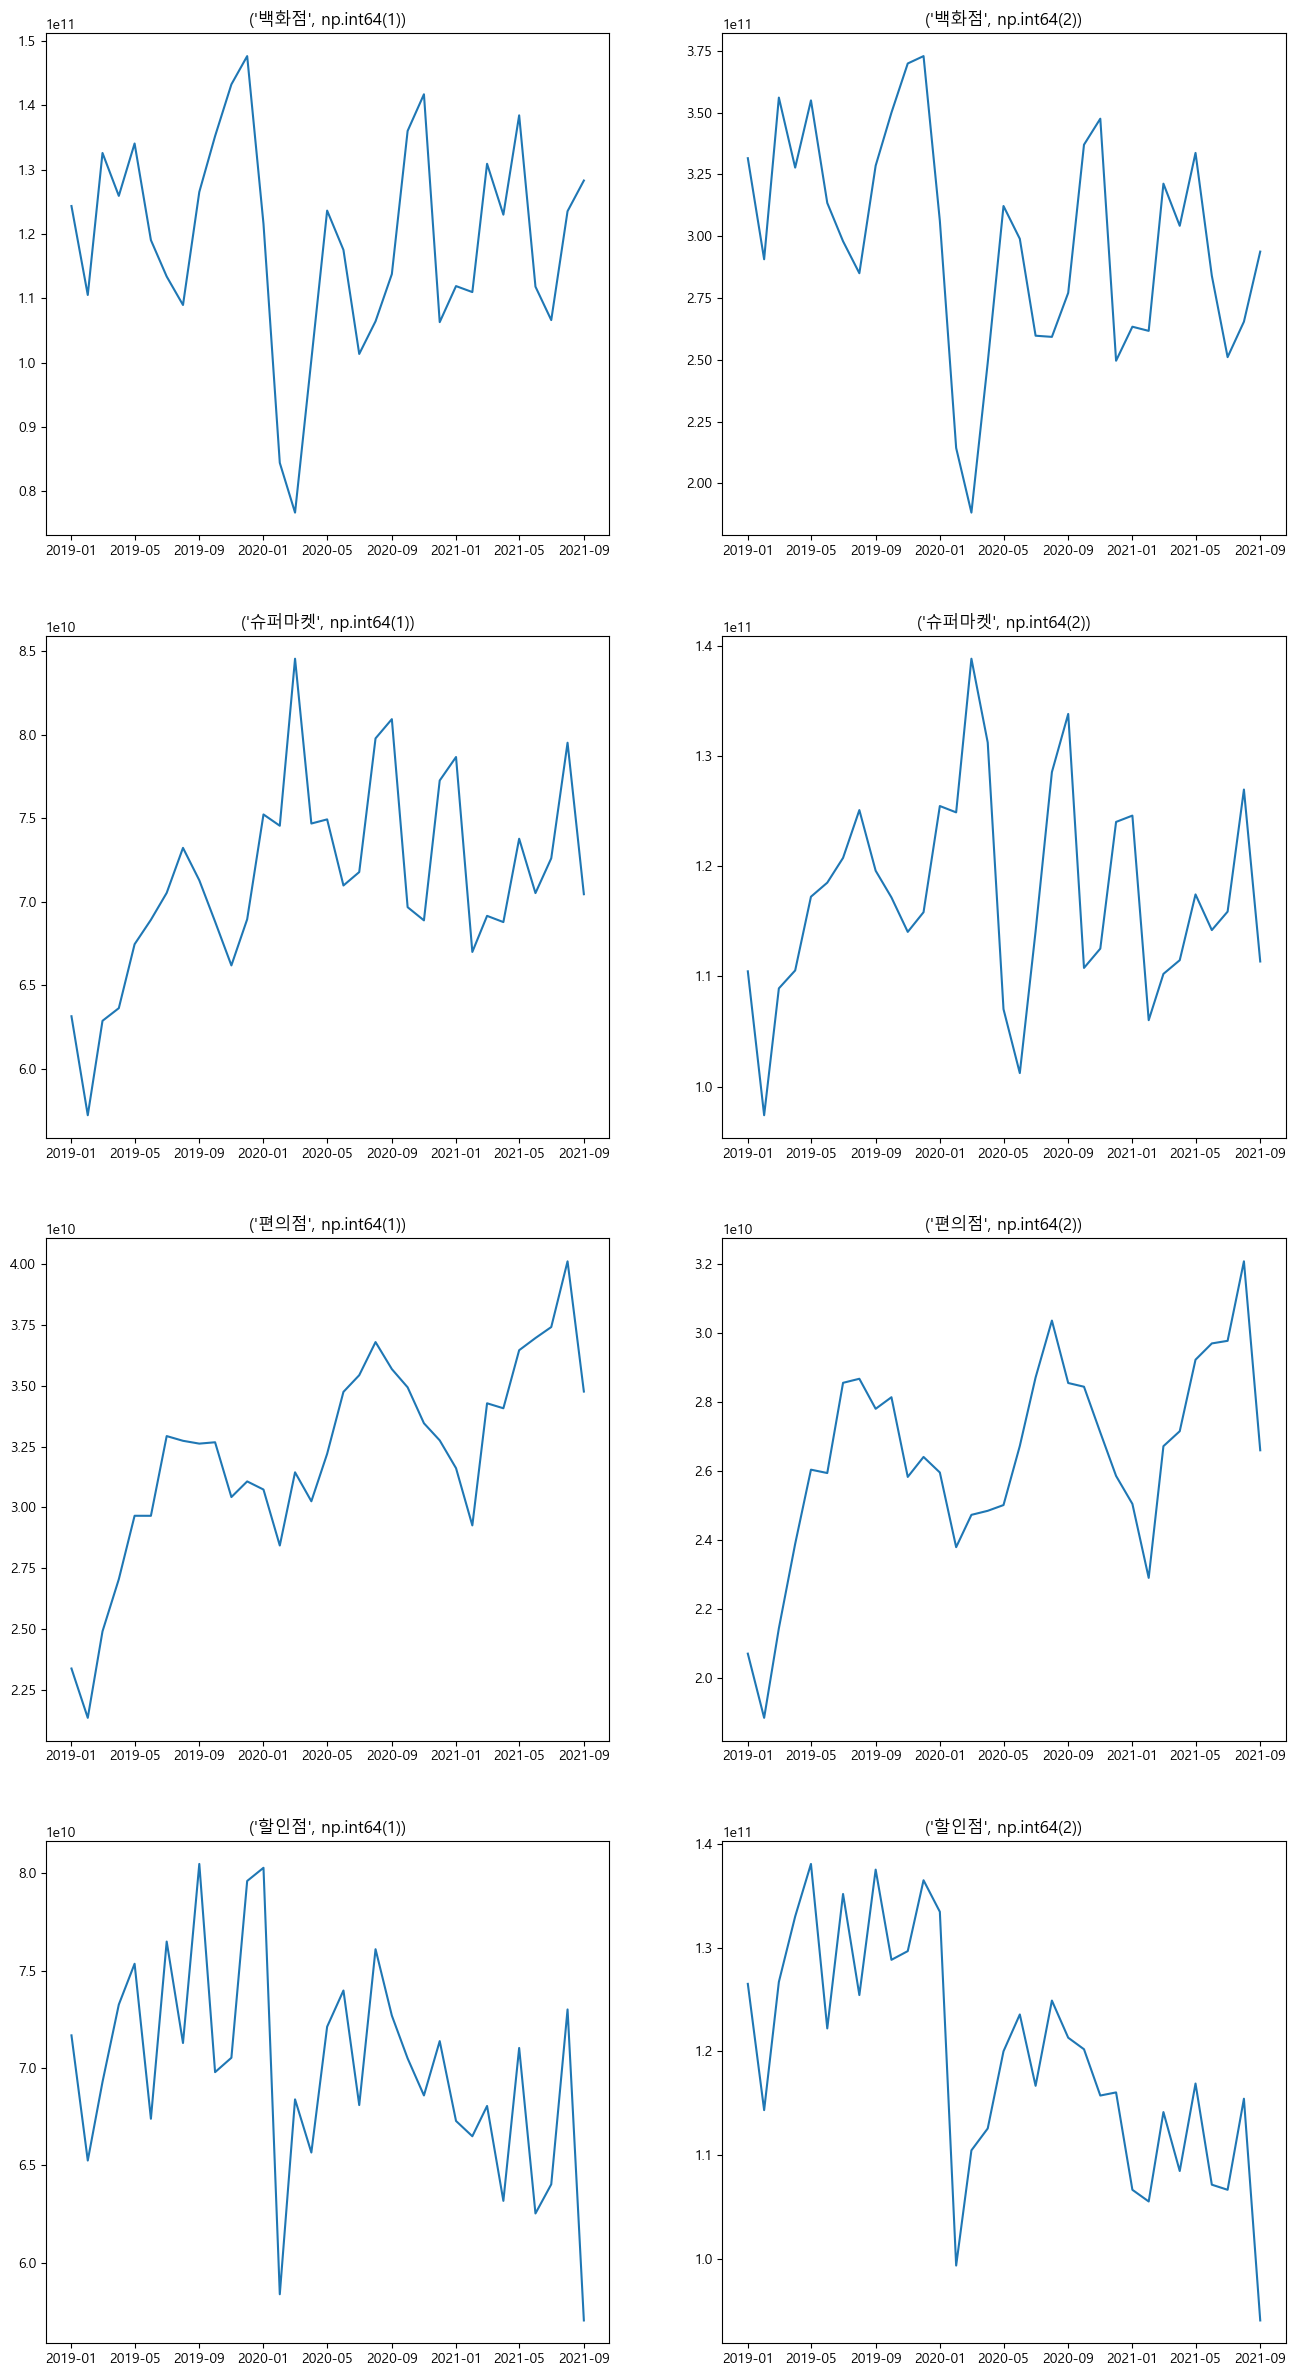

In [118]:
# subplots() 버전
row_num = 4
col_num = 2
# subplots() -> 2개의 데이터를 리턴 (캔버스, 영역)
# fig -> 캔버스 
fig, axes = plt.subplots(row_num, col_num, figsize = (16, 30))

for i in range( len( group_data3.columns ) ):
    rows = i // col_num
    cols = i % col_num

    axes[rows][cols].plot( group_data3.iloc[:, i])
    # 그래프에 이름을 넣어라
    # plt인 캔버스를 선택하는것이 아니라 영역을 선택 
    # plt.title(group_data3.columns[i])
    # axes 영역에서는 title()함수가 존재하지 않는다. -> set_title() 함수를 이용
    axes[rows][cols].set_title(group_data3.columns[i])


# plt.savefig('subnplots.png')
fig.savefig('subplots.png')

fig.show()

- 오프라인, 온라인 데이터를 로드 
- 데이터들을 확인 
- 두개의 데이터프레임을 결합(유니언, 조인)
    - 유니언 
        - 단순한 행 결합 ( 두개의 데이터프레임의 구조가 같은 경우 )
    - 조인 
        - 특정컬럼의 데이터가 같은 경우 조건에 맞춰서 열을 결합 
- 온라인에서 총 이용금액과 오프라인에서의 총 이용금액을 기간에 따라 어떻게 바뀌는가? 확인 

In [119]:
offline = pd.read_csv("../csv/card/오프라인.csv", encoding='cp949')
online = pd.read_csv("../csv/card/온라인.csv", encoding='cp949')

In [120]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   crym          2648 non-null   int64  
 1   tco_btc_nm    2648 non-null   object 
 2   ma_fem_dc     2648 non-null   int64  
 3   agegrp_dc     2648 non-null   int64  
 4   tco_btc_u_ct  2648 non-null   int64  
 5   tco_btc_u_am  2648 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 124.3+ KB


In [121]:
online.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   crym          651 non-null    int64
 1   ma_fem_dc     651 non-null    int64
 2   agegrp_dc     651 non-null    int64
 3   tco_btc_u_ct  651 non-null    int64
 4   tco_btc_u_am  651 non-null    int64
dtypes: int64(5)
memory usage: 25.6 KB


In [122]:
# 온라인 성별 컬럼에 9라는 데이터가 존재하는가?
online['ma_fem_dc'].describe()

count    651.000000
mean       1.499232
std        0.500384
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        2.000000
Name: ma_fem_dc, dtype: float64

In [123]:
online['ma_fem_dc'].value_counts()

ma_fem_dc
1    326
2    325
Name: count, dtype: int64

In [124]:
online.describe()

,crym,ma_fem_dc,agegrp_dc,tco_btc_u_ct,tco_btc_u_am
count,651.000000,651.000000,651.000000,6.510000e+02,6.510000e+02
mean,201998.135177,1.499232,45.631336,9.606536e+05,4.940927e+10
std,78.678490,0.500384,28.432958,1.443702e+06,6.914516e+10
min,201901.000000,1.000000,0.000000,1.000000e+00,5.000000e+02
25%,201909.000000,1.000000,20.000000,3.481500e+03,1.467190e+08
50%,202005.000000,1.000000,50.000000,1.969560e+05,1.449364e+10
75%,202101.000000,2.000000,70.000000,1.330438e+06,7.999589e+10
max,202109.000000,2.000000,90.000000,6.824744e+06,3.065816e+11


In [125]:
offline.describe()

,crym,ma_fem_dc,agegrp_dc,tco_btc_u_ct,tco_btc_u_am
count,2648.000000,2648.000000,2648.000000,2.648000e+03,2.648000e+03
mean,201996.672205,1.504532,44.878776,3.309869e+05,1.064912e+10
std,78.829105,0.500074,28.768254,4.645646e+05,1.755371e+10
min,201901.000000,1.000000,0.000000,1.000000e+00,1.500000e+03
25%,201909.000000,1.000000,20.000000,9.407500e+02,2.652966e+07
50%,202005.000000,2.000000,40.000000,1.053975e+05,2.589632e+09
75%,202101.000000,2.000000,70.000000,4.907440e+05,1.457397e+10
max,202109.000000,2.000000,90.000000,2.343320e+06,1.116790e+11


In [126]:
# 두개의 데이터프레임의 이름을 변경 
offline.columns = ['기준년월', '업종', '성별', '연령대' ,'이용건수', '이용금액']
online.columns = ['기준년월', '성별', '연령대', '이용건수', '이용금액']

In [127]:
# 두개의 데이터프레임의 구조가 약간 다르다. online 데이터에는 업종 컬럼이 존재x
# 결합하고 업종 결측치에 데이터를 채워주는 방법 
# online 업종 컬럼을 생성하고 그 후에 결합 

In [129]:
# 단순 결합 concat() -> 여러개의 데이터프레임을 결합 가능 ( 첫번째 인자에 데이터프레임 목록 입력 )
df = pd.concat( [ offline, online ], axis = 0, ignore_index=True )

In [131]:
# df안에 업종 컬럼에 결측치를 특정한 값으로 대체 
df['업종'] = df['업종'].fillna('온라인')

In [132]:
# online에 업공 컬럼을 추가 하고 '온라인'으로 모두 채워준다. 
online['업종'] = '온라인'

In [ ]:
online

In [134]:
offline.columns

Index(['기준년월', '업종', '성별', '연령대', '이용건수', '이용금액'], dtype='object')

In [135]:
online.columns

Index(['기준년월', '성별', '연령대', '이용건수', '이용금액', '업종'], dtype='object')

In [136]:
df2 = pd.concat( [offline, online], axis=0, ignore_index=True )

In [137]:
df2.isna().sum()

기준년월    0
업종      0
성별      0
연령대     0
이용건수    0
이용금액    0
dtype: int64

In [138]:
df.isna().sum()

기준년월    0
업종      0
성별      0
연령대     0
이용건수    0
이용금액    0
dtype: int64

<Axes: xlabel='기준년월'>

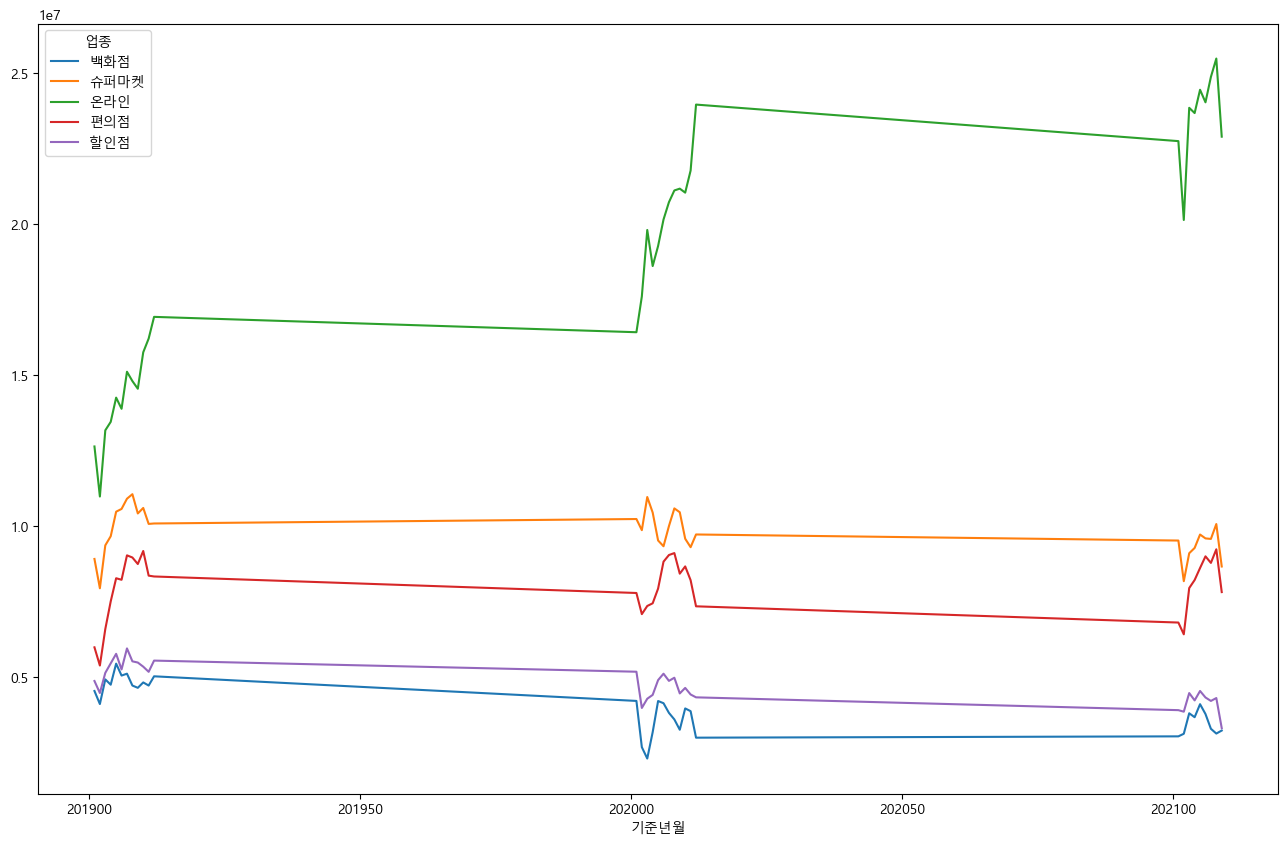

In [140]:
pd.pivot_table(
    df, 
    index = '기준년월', 
    columns = '업종', 
    values = '이용건수', 
    aggfunc= 'sum'
).plot(figsize=(16, 10))

In [141]:
# 기준년월 시계열로 변경 
df['기준년월'] = pd.to_datetime(df['기준년월'], format='%Y%m')

df2['기준년월'] = pd.to_datetime(df2['기준년월'])

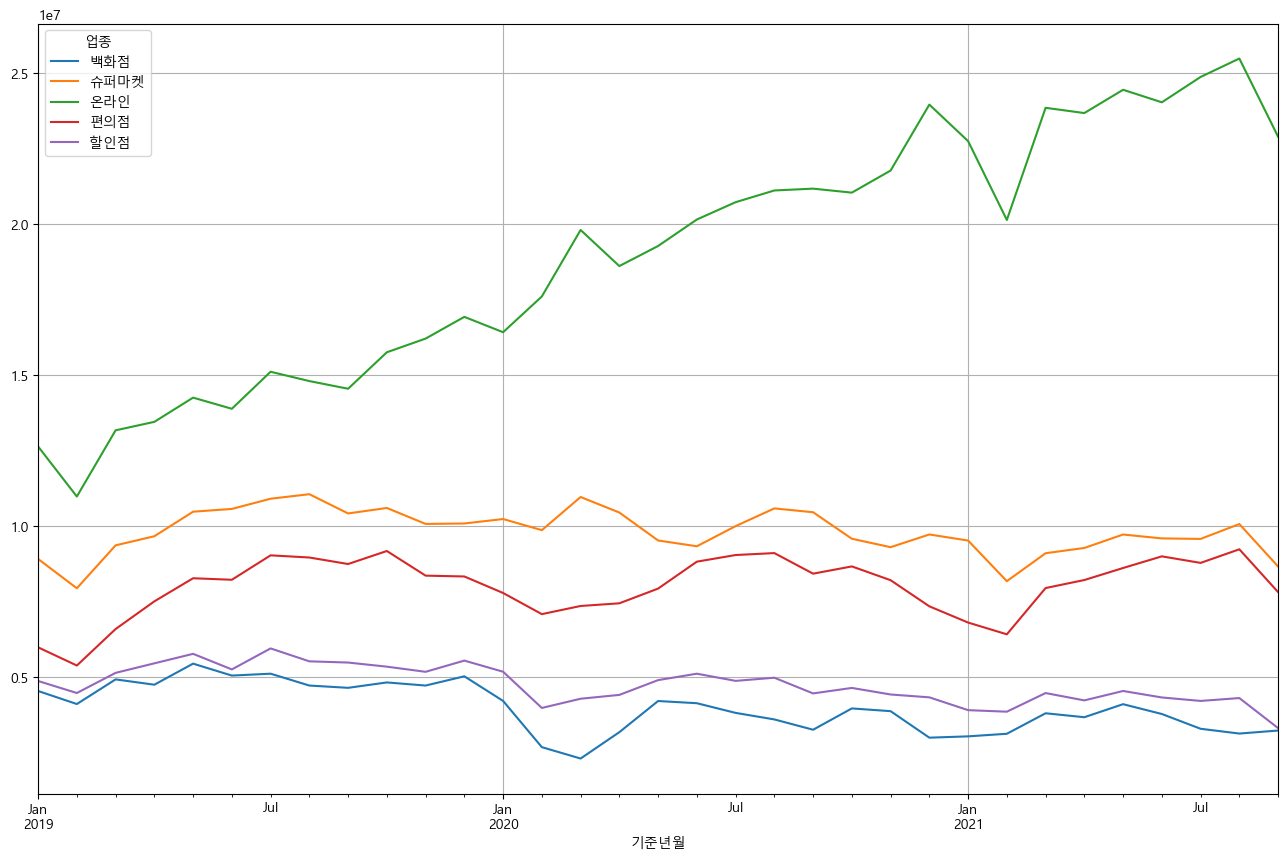

In [ ]:
pd.pivot_table(
    df, 
    index = '기준년월', 
    columns = '업종', 
    values = '이용건수', 
    aggfunc= 'sum'
).plot(figsize=(16, 10))
# 그래프에 격자선 추가 
plt.grid(True)

In [ ]:
pd.pivot_table(
    df2, 
    index = '기준년월', 
    columns = '업종', 
    values = '이용건수', 
    aggfunc= 'sum'
).plot(figsize=(16, 10))

- 온라인 / 오프라인을 기준으로 기준년월 총이용금액의 합계를 그래프 표시 

In [ ]:
# 반복문 -> 2개의 리스트를 생성 온라인인 데이터, 온라인 아닌 데이터 
online_idx = []
offline_idx = []

for i in range( len(df) ):
    # i -> index 값들이 하나씩 대입 
    if df.loc[i, '업종'] == '온라인':
        online_idx.append(i)
    else:
        offline_idx.append(i)

online_idx

In [ ]:
online_df = df.loc[online_idx, ]
online_df

In [148]:
offline_df = df.loc[offline_idx, ]

In [149]:
online_group = online_df.groupby('기준년월')['이용금액'].sum()
offline_group = offline_df.groupby('기준년월')['이용금액'].sum()

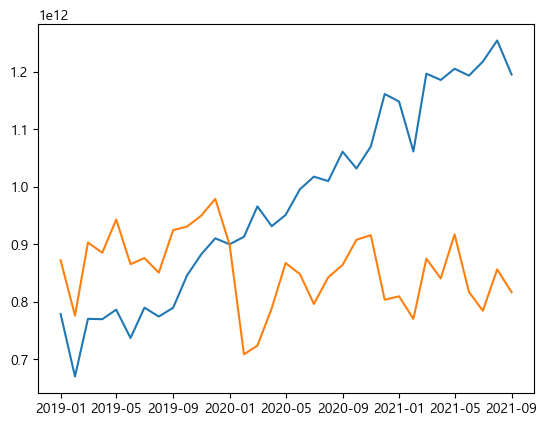

In [151]:
plt.plot(online_group)
plt.plot(offline_group)

In [ ]:
# 파생변수 생성 -> on/off -> 온라인 1, 오프라인 0
# 업종 컬럼을 선택해서 map() 함수를 이용해서 온라인인지 판단 -> int() 변환해서 새로운 컬럼에 대입 
df['업종'].map(
    lambda x : int(x == '온라인')
)

In [158]:
# 한줄로 if문 표시 -> 참일경우결과 if 조건식 else 거짓인경우결과
df['on/off'] = df['업종'].map(
    lambda x : 'on' if x == '온라인' else 'off'
)

<Axes: xlabel='기준년월'>

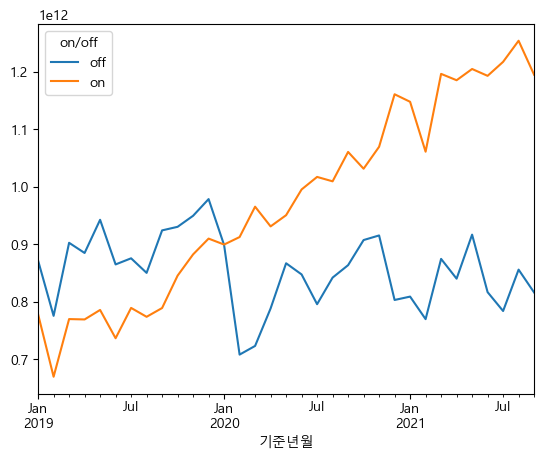

In [159]:
pd.pivot_table(
    df, 
    index = '기준년월', 
    columns = 'on/off', 
    values = '이용금액', 
    aggfunc= 'sum'
).plot()

In [161]:
# 기준년월, 업종을 기준으로 그룹화 이용금액의 합산 
group_data5 = df[ ['기준년월', '업종', '이용금액'] ].groupby( ['기준년월', '업종'] ).sum()

In [164]:
group_data5 = group_data5.unstack()

In [167]:
# group_data5에서 온라인 컬럼을 제외하고 나머지의 데이터들의 합산 오프라인 컬럼을 생성
group_data5 = group_data5['이용금액']

In [ ]:
# 4개의 컬럼을 모두 더한다. 
group_data5['백화점'] + group_data5['할인점'] + group_data5['슈퍼마켓'] + group_data5['편의점']

In [172]:
# 온라인 제외하고 모두 더한다. 
group_data5['오프라인'] = group_data5.drop('온라인', axis=1).sum(axis=1)

C:\Users\ekfla\AppData\Local\Temp\ipykernel_21496\3238742254.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_data5['오프라인'] = group_data5.drop('온라인', axis=1).sum(axis=1)


In [ ]:
group_data5

In [ ]:
plt.plot(group_data5['온라인'])
plt.plot(group_data5['오프라인'])
plt.legend(['온라인', '오프라인'])
plt.show()

In [ ]:
plt.plot(group_data5['온라인'], label='온라인')
plt.plot(group_data5['오프라인'], label='오프라인')
plt.legend()
plt.show()

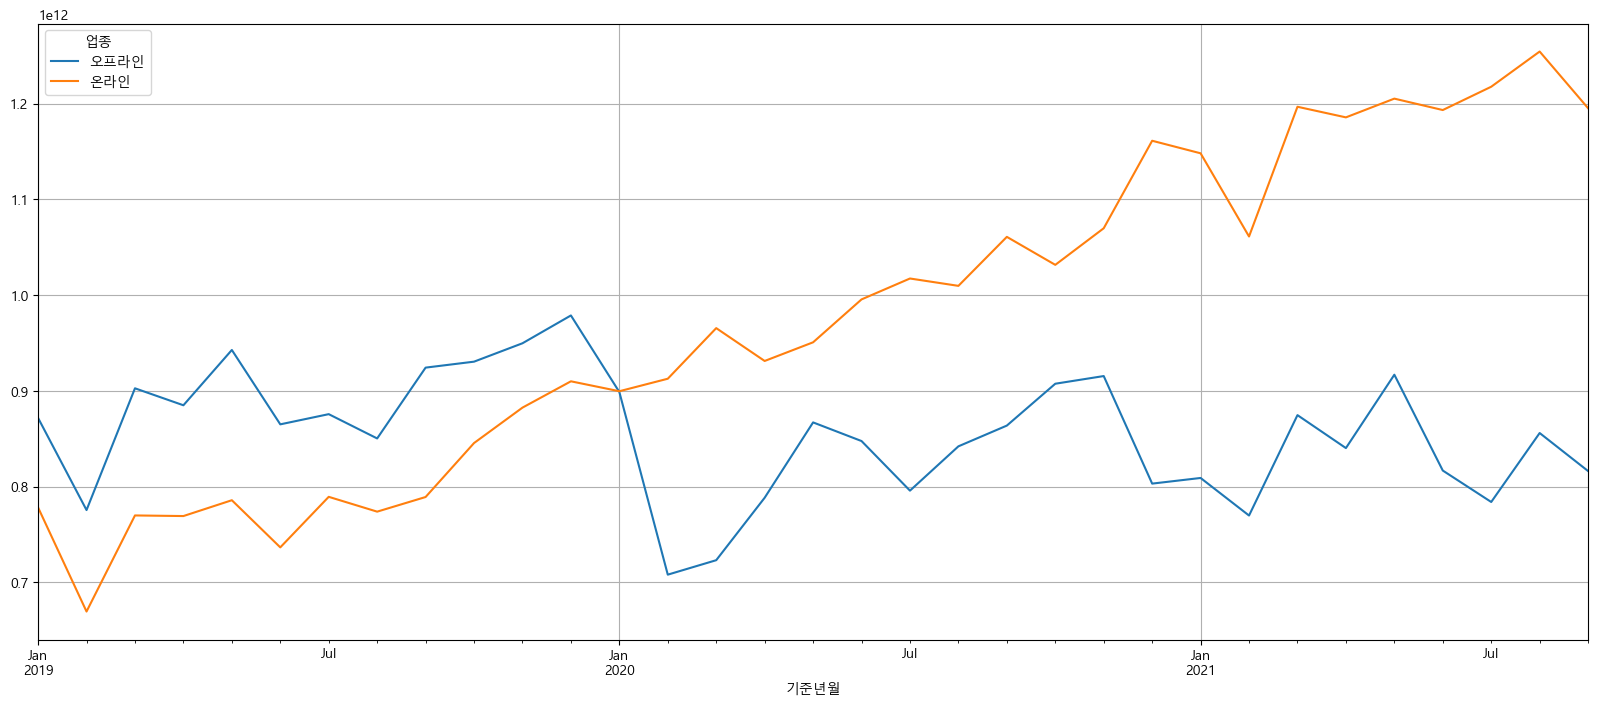

In [180]:
pd.pivot_table(
    df, 
    index = '기준년월', 
    columns = [df['업종'] == '온라인'], 
    values = '이용금액', 
    aggfunc= 'sum'
).rename(columns = {
    False : '오프라인', 
    True : '온라인'
}).plot(figsize = (20, 8))
plt.grid(True)